# Reproduction walkthrough — Market Impact Estimation via Causal Foundation Models

This notebook reproduces, at smoke scale (CPU, a few minutes), each pillar of the paper's
evidence, and maps every figure/table to the script that generates it at full scale.

The paper's claim in one sentence: *market impact is a counterfactual*
($E[Y \mid \mathrm{do}(A)]$, not $E[Y \mid A]$), and a continuous-time causal PFN trained on
a market prior with **calibrated hidden confounding** learns to answer the interventional
question in context — including zero-shot on markets it never saw.

Structure:
0. Reading guide: the model for three audiences, the prior's DAG, and where each ingredient comes from.
1. The confounding law — the closed-form bias of naive regression, verified empirically.
2. One counterfactual pair — the shared-noise exactness the whole evaluation rests on.
3. The paired do-head readout — causal model vs. its do-ablated twin (needs checkpoints).
4. Off-prior stress — exact counterfactuals from generators outside the prior's class.
5. Full-scale reproduction map and protocol summary.


## 0. Reading guide — three fields, one model

This paper sits at the intersection of financial mathematics, machine learning, and
causal inference, and few readers are native to all three. Each field needs a different
bridge:

- **If you come from ML**: an SDE is a *continuous-time recurrence*. The model below is
  the continuous-time sibling of an AR(1)/linear-RNN update; "training a PFN" is ordinary
  supervised pretraining on synthetic tasks, and using it is in-context learning — the
  frozen transformer reads one episode's history as its prompt and emits a posterior
  predictive. No stochastic calculus is required beyond "how to read Eq. 1" below.
- **If you come from causal inference**: everything is a linear-Gaussian structural
  causal model, just indexed by continuous time. There is one hidden confounder, no valid
  adjustment set, and therefore no identification from data — the *prior* supplies
  identification, which is the paper's central honest claim.
- **If you come from finance**: $\lambda$ is permanent price impact, the naive regression
  below is the standard empirical impact estimation, and the hidden variable formalizes
  informed ("core") flow whose information leaks into the price. This is the familiar
  "impact estimates are contaminated by alpha" problem: informed participants trade on
  information that would have moved the price anyway, so a regression of price on flow
  credits the trade with moves the trader merely anticipated — over-stating mechanical
  impact.

### How to read the generative equation (paper Eq. 1)

Every episode is drawn from a linear-drift SDE over $d$ variables in a directed acyclic
graph (DAG):

$$dX_v = \Big(\underbrace{-\theta_v X_v}_{\text{mean reversion}}
        + \underbrace{\textstyle\sum_{u \in \mathrm{pa}(v)} w_{vu} X_u}_{\text{parents push}}\Big)\,dt
        + \underbrace{\sigma_v\, dW_v}_{\text{noise}}$$

Subscripts: $v$ indexes the graph's variables (variable $X_v$; one SDE per node), and
$u$ ranges over the parents $\mathrm{pa}(v)$ in the DAG, with $w_{vu}$ the edge weight from parent
$u$ to child $v$. In the market instantiation below the three nodes are *named*
rather than numbered — $X_v \in \{U, A, Y\}$ — so, e.g., the price equation has
$\mathrm{pa}(Y) = \{A, U\}$ with weights $\lambda$ and $\gamma$. (The named node $U$
and the generic parent index $u$ are unrelated symbols; the index notation appears
only in Eq. 1.)

Read it as a recurrence over a tiny time step $\Delta t$ (this is literally how it is
simulated — Euler–Maruyama is a for-loop):

$$X_v(t+\Delta t) \;\approx\; \underbrace{X_v(t)}_{\text{current state}} + \underbrace{\big({-\theta_v X_v(t)} + \textstyle\sum_u w_{vu} X_u(t)\big)\,\Delta t}_{\text{drift} \times \text{time step}} + \underbrace{\sigma_v\,\sqrt{\Delta t}\,\varepsilon}_{\text{noise, scaled by }\sqrt{\Delta t}},\qquad \varepsilon \sim \mathcal N(0,1)$$

- $-\theta_v X_v$: the variable decays toward zero at rate $\theta_v$ (an
  Ornstein–Uhlenbeck process — the continuous-time AR(1); in finance, inventory control
  and mean reversion).
- $\sum w_{vu} X_u$: each parent in the DAG pushes its child with edge weight $w_{vu}$ —
  this is where the *causal structure* lives.
- $\sigma_v\,dW_v$: independent Gaussian noise per unit time ($W_v$ is a Wiener process;
  the $\sqrt{\Delta t}$ scaling is why simulation needs care, not deep theory).

The market prior instantiates this with $d=3$ variables — that is the *entire* formal
content of "continuous-time" here.


In [1]:
import math
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import torch
import matplotlib.pyplot as plt

from pathlib import Path

# Importing dotime_market.baselines has a side effect: every baseline
# (Almgren-Chriss, propagator, square-root law, ...) registers itself in the
# released dotime package's baseline registry, so get("<name>") works below.
import dotime_market.baselines
from dotime.baselines import get
from dotime_market.data.synthetic import build_market_suite
from dotime_market.prior.market_scm import MarketDoTime

SEED = 0
torch.manual_seed(SEED)
np.random.seed(SEED)

# Prior hyper-parameters of the paper's evaluation grid (scripts/01b):
#   core_share=0.7   -> 70% of the observable flow's variance is core-driven,
#                       i.e. strong hidden confounding (the hard regime);
#   impact_lambda    -> per-episode range of the true causal effect lambda;
#   theta/sigma      -> OU mean-reversion and diffusion ranges for U, A, Y;
#   num_substeps=2   -> Euler-Maruyama fine-grid steps per observation bar
#                       (keeps theta*dt well inside the stability region).
PRIOR_KW = dict(core_share=0.7, impact_lambda=(0.25, 1.0), theta_range=(0.5, 1.0),
                sigma_range=(0.2, 0.6), num_substeps=2)
print("setup ok")

setup ok


### The prior's DAG, and what do($A$) does to it

The three-variable instantiation (paper Eqs. 2–4; symbols defined by this paper):

$$dU = \underbrace{-\theta_U U\,dt}_{\text{mean reversion}} + \sigma_U\,dW_U \qquad \text{hidden informational core flow}$$
$$dA = \big(\underbrace{-\theta_A A}_{\text{inventory control}} + \underbrace{w\,U}_{\substack{\text{informed trading:}\\\text{core drives flow}}}\big)\,dt + \sigma_A\,dW_A \qquad \text{observable order flow}$$
$$dY = \big(\underbrace{-\theta_Y Y}_{\text{mean reversion}} + \underbrace{\lambda A}_{\substack{\text{mechanical impact}\\\text{(the estimand)}}} + \underbrace{\gamma U}_{\substack{\text{information leaks}\\\text{into the price}}}\big)\,dt + \sigma_Y\,dW_Y \qquad \text{price}$$

The left panel below is the observational world: the back-door path
$A \leftarrow U \rightarrow Y$ runs through the *hidden* $U$, so a regression of $Y$ on
$A$ mixes the causal channel $\lambda$ with the informational channel $\gamma$. The right
panel is the *intervened* world: $\mathrm{do}(A)$ is **graph surgery** — the intervention
sets $A$ regardless of $U$, severing the arrow $U \to A$ and with it the back-door path.
The paper's estimand $E[Y \mid \mathrm{do}(A)]$ lives in the right graph; data is only
ever observed in the left one. That mismatch is the whole problem.


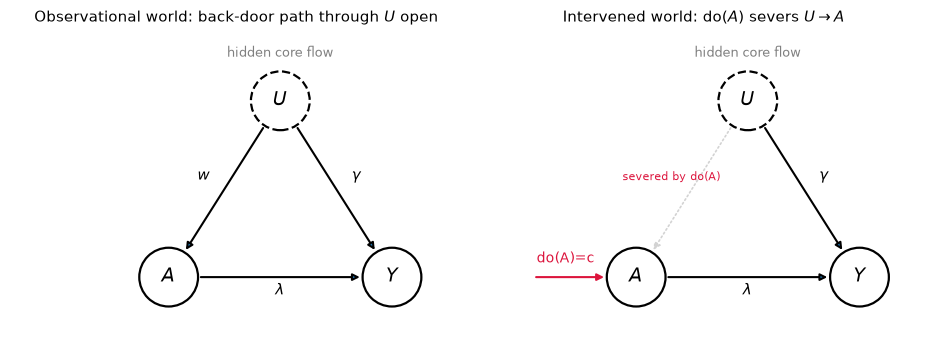

Estimand: E[Y | do(A)] -- the lambda channel alone (right graph).
Data:     only the left graph is ever observed; U is never recorded.


In [2]:
def draw_market_dag(ax, intervened, title):
    """Draw the 3-node market DAG; the dashed node is the hidden variable.

    intervened=True draws the post-surgery graph of do(A): the U->A edge is
    severed and an exogenous intervention arrow sets A instead.
    """
    pos = {"U": (0.5, 0.78), "A": (0.12, 0.18), "Y": (0.88, 0.18)}
    R = 0.10
    for name, (x, y) in pos.items():
        ax.add_patch(plt.Circle((x, y), R, fill=False, lw=1.6,
                                ls="--" if name == "U" else "-"))
        ax.text(x, y, f"${name}$", ha="center", va="center", fontsize=14)
    ax.text(pos["U"][0], pos["U"][1] + R + 0.05, "hidden core flow",
            ha="center", fontsize=9, color="gray")

    def edge(f, t, label, off=(0, 0), removed=False):
        (x1, y1), (x2, y2) = pos[f], pos[t]
        d = np.hypot(x2 - x1, y2 - y1)
        # shrink so arrows start/end at circle boundaries, not centers
        sx, sy = x1 + (x2 - x1) * R / d, y1 + (y2 - y1) * R / d
        ex, ey = x2 - (x2 - x1) * R / d, y2 - (y2 - y1) * R / d
        if removed:
            ax.annotate("", (ex, ey), (sx, sy), arrowprops=dict(
                arrowstyle="-|>", color="lightgray", ls=":", lw=1.2))
            ax.text((sx + ex) / 2 + off[0], (sy + ey) / 2 + off[1],
                    "severed by do(A)", fontsize=8, color="crimson", ha="center")
        else:
            ax.annotate("", (ex, ey), (sx, sy),
                        arrowprops=dict(arrowstyle="-|>", lw=1.5))
            ax.text((sx + ex) / 2 + off[0], (sy + ey) / 2 + off[1], label,
                    fontsize=11, ha="center")

    edge("U", "A", "$w$", off=(-0.07, 0.03), removed=intervened)
    edge("U", "Y", r"$\gamma$", off=(0.07, 0.03))   # informational channel
    edge("A", "Y", r"$\lambda$", off=(0, -0.06))    # mechanical impact = the estimand
    if intervened:
        ax.annotate("", (pos["A"][0] - R, pos["A"][1]),
                    (pos["A"][0] - 0.35, pos["A"][1]),
                    arrowprops=dict(arrowstyle="-|>", lw=1.5, color="crimson"))
        ax.text(pos["A"][0] - 0.24, pos["A"][1] + 0.05, "do(A)=c",
                color="crimson", fontsize=10, ha="center")
    ax.set_xlim(-0.42, 1.12); ax.set_ylim(0, 1.02)
    ax.set_aspect("equal"); ax.axis("off"); ax.set_title(title, fontsize=11)

fig, axes = plt.subplots(1, 2, figsize=(9.5, 3.4))
draw_market_dag(axes[0], intervened=False,
                title="Observational world: back-door path through $U$ open")
draw_market_dag(axes[1], intervened=True,
                title="Intervened world: do($A$) severs $U \\rightarrow A$")
plt.tight_layout(); plt.show()

print("Estimand: E[Y | do(A)] -- the lambda channel alone (right graph).")
print("Data:     only the left graph is ever observed; U is never recorded.")


### Where each ingredient comes from

Three cited sources supply three different things, and the symbols $U, A, Y$ appear in none of them; they are *defined by this paper*:

| Ingredient | Source |
|---|---|
| The **economic decomposition** — order flow splits into exogenous *informational core* flow and endogenous *reaction* flow | Muhle-Karbe et al., arXiv:2601.23172 (concept only; their analysis uses their own formalism) |
| The **estimand** — impact is the realized price path minus the counterfactual path without the trade | Bonart (cited in §1/§2) |
| The **episode machinery** — generic linear-drift SDE over a DAG (paper Eq. 1), Euler–Maruyama integration, counterfactual pair generation | the continuous-time causal-PFN construction cited in §3 |
| The **three-variable instantiation** $U \to A$, $U \to Y$, $A \to Y$, with symbols $U, A, Y$ and the calibration below | **this paper**, §4, Eqs. 2–4 |

The causal graph: $U$ is a *hidden confounder* of the $A \to Y$ relation. $A$ moves $Y$
mechanically through $\lambda$ (the causal effect we want), but $U$ moves *both* $A$
(informed traders trade) and $Y$ (information moves prices, weight $\gamma$). A regression
of $Y$ on $A$ therefore absorbs part of the informational channel into its slope — the
classic back-door bias, here with an exact closed form (§1 below).


### The two calibration formulas (paper Eqs. 5–6)

**Eq. 5 — the edge weight $w$ realizing a target core share $s$.** We do not sample the
$U \to A$ weight directly; we sample the *fraction of flow variance that is core-driven*
and solve for the weight that produces it exactly (a stationary Lyapunov calculation):

$$w \;=\; \sqrt{\;\underbrace{\frac{s}{1-s}}_{\substack{\text{odds of the}\\\text{core share}}}\;\cdot\;\underbrace{\frac{\sigma_A^2 / (2\theta_A)}{\vphantom{\Big(}}}_{\substack{\text{reaction-driven}\\\text{flow variance}}}\;\Big/\;\underbrace{\frac{\mathrm{Var}(U)}{\theta_A(\theta_A+\theta_U)}}_{\substack{\text{core-driven flow variance}\\\text{per unit } w^2}}\;}\qquad\text{with } \mathrm{Var}(U)=\frac{\sigma_U^2}{2\theta_U}.$$

Why this matters: confounding *strength* becomes an exact, per-episode-samplable quantity
(a knob), instead of an uncontrolled by-product of random weights.

**Eq. 6 — the confounding component of the naive slope.** The excess of the naive OLS
slope over its $\gamma = 0$ value, in closed form:

$$\mathrm{bias}_{\mathrm{OLS}}(\gamma) \;=\; \frac{\gamma\,\Big(\underbrace{\mathrm{Cov}(A,U)}_{\substack{\text{direct: flow}\\\text{co-moves with core}}} \;+\; \underbrace{w\,\mathrm{Var}(U)/(\theta_Y+\theta_U)}_{\substack{\text{indirect: core leaks into}\\\text{price, price tracks flow}}}\Big)}{\underbrace{(\theta_Y+\theta_A)\,\mathrm{Var}(A)}_{\substack{\text{regression denominator}\\\times\text{ price low-pass}}}}$$

Linear in $\gamma$, and zero when either channel closes ($\gamma = 0$: no information
leak; $s = 0 \Rightarrow \mathrm{Cov}(A,U) = w = 0$: no informed flow). Section 1 below
verifies exactly this law empirically; the implementation lives in
`src/dotime_market/prior/confounding.py` (Eq. 5) and `coupling.py` (Eq. 6), each with
reduction tests.


### Notation table

Every mathematical symbol used in this notebook, in order of appearance.

| Symbol | Meaning | Introduced |
|---|---|---|
| $X_v$ | the state of variable $v$ (one SDE per node of the DAG) | Eq. 1 |
| $v$ | index over the graph's variables (nodes) | Eq. 1 |
| $u$ | index over the parents of $v$; unrelated to the named node $U$ | Eq. 1 |
| $\mathrm{pa}(v)$ | the parent set of node $v$ in the DAG | Eq. 1 |
| $w_{vu}$ | edge weight from parent $u$ to child $v$ | Eq. 1 |
| $\theta_v$ | mean-reversion rate of $X_v$ (decay toward zero; OU speed) | Eq. 1 |
| $\sigma_v$ | diffusion coefficient (noise scale per unit time) of $X_v$ | Eq. 1 |
| $W_v$, $dW_v$ | independent standard Wiener process and its increment | Eq. 1 |
| $\Delta t$, $\varepsilon$ | time step and standard-normal draw of the Euler–Maruyama recurrence | Eq. 1 (recurrence view) |
| $U$ | hidden informational "core" flow — the confounder (named node) | Eqs. 2–4 |
| $A$ | observable order flow — the intervention target | Eqs. 2–4 |
| $Y$ | price — the outcome | Eqs. 2–4 |
| $w$ | the single $U \to A$ edge weight (core drives flow) | Eq. 3 |
| $\gamma$ | informational coupling, the $U \to Y$ weight — confounding strength knob | Eq. 4 |
| $\lambda$ | mechanical impact, the $A \to Y$ weight — **the causal effect of interest** | Eq. 4 |
| $s$ | core share: fraction of $A$'s stationary variance driven by $U$; realizes $w$ via a Lyapunov solve | §0 calibration |
| $\mathrm{do}(A)$, $E[Y \mid \mathrm{do}(A)]$ | intervention on $A$ (graph surgery: $U \to A$ severed) and the interventional mean — the estimand | DAG figure |
| $c$ | the intervention's clamp value: $\mathrm{do}(A := c)$ during the window | §2 |
| $T$ | number of observation bars per episode (here $T = 120$) | §1 |
| onset, end | first and one-past-last bar of the intervention window | §2 |
| `y_true` | the exact counterfactual outcome from the shared-noise pair | §3 |
| signed error | $\mathrm{sign}(c)\,(\hat{y} - y_{\text{true}})$, so positive bias = over-predicted impact for buys and sells alike | §3 |


## 1. The confounding law

Because $U$ is hidden, the naive OLS slope of price on flow does not estimate the causal
effect: it over-shoots by an amount that is **linear in $\gamma$ and zero when either
channel closes** (paper Eq. 6). Every generated episode carries its analytic naive and
interventional slopes in metadata, so the law is checkable *without any trained model*:
we compare the empirical OLS slope, computed from the observational data alone, against
the analytic means per $\gamma$.

(Full scale: `scripts/01_bias_vs_gamma.py`, n=2000/point → paper Fig. 1, measured
$\gamma$-gradient 0.326 vs. 0.332 analytic.)

 gamma  naive emp  naive ana   do ana
   0.0      0.429      0.580    0.886
   1.0      0.904      1.069    0.886
   2.0      1.380      1.558    0.886


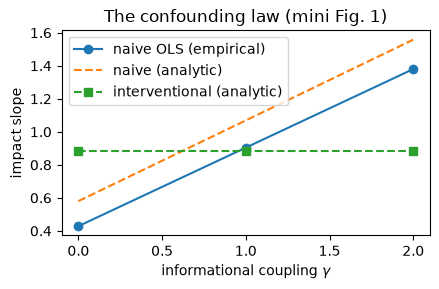

In [3]:
gammas = [0.0, 1.0, 2.0]   # informational coupling: none / moderate / strong
N_MINI = 120               # smoke scale; the paper uses n=2000 per gamma point

rows = []
for g in gammas:
    # A fresh prior with gamma PINNED to g (training samples gamma per episode;
    # evaluation grids pin it so the x-axis of Fig. 1 is well-defined).
    prior = MarketDoTime(coupling_gamma=g, seed=SEED, **PRIOR_KW)
    suite = build_market_suite(prior, n_episodes=N_MINI, T=120, seed=SEED)

    naive_emp = []
    for ep in suite:
        # ep.x_obs is the OBSERVATIONAL trajectory, shape (T, 3) with the
        # canonical column order (A, U, Y). The hidden core column is zeroed
        # in the observables -- that U is unobserved is the whole point --
        # so column 0 is flow A and column 2 is price Y.
        x = ep.x_obs.numpy()

        # Fit on the PRE-intervention window only: the naive practitioner
        # regresses price on flow from historical (observational) data,
        # before any metaorder is executed.
        onset = min(ep.intervention.times)
        a, y = x[:onset, 0], x[:onset, 2]

        # Plain one-variable OLS slope: cov(A, Y) / var(A). Under hidden
        # confounding this absorbs the informational channel -- that is the
        # bias the paper's Eq. 6 quantifies.
        a_c = a - a.mean()
        naive_emp.append(float((a_c * (y - y.mean())).sum() / max((a_c * a_c).sum(), 1e-8)))

    rows.append({
        "gamma": g,
        # empirical naive slope, averaged over episodes:
        "naive_emp": float(np.mean(naive_emp)),
        # analytic counterparts, computed per episode from the true SCM
        # parameters (available because WE generated the episodes):
        "naive_ana": float(np.mean([ep.metadata["naive_slope_ana"] for ep in suite])),
        "do_ana": float(np.mean([ep.metadata["do_slope_ana"] for ep in suite])),
    })

print(f"{'gamma':>6} {'naive emp':>10} {'naive ana':>10} {'do ana':>8}")
for r in rows:
    print(f"{r['gamma']:6.1f} {r['naive_emp']:10.3f} {r['naive_ana']:10.3f} {r['do_ana']:8.3f}")

g_ = [r["gamma"] for r in rows]
plt.figure(figsize=(4.5, 3))
plt.plot(g_, [r["naive_emp"] for r in rows], "o-", label="naive OLS (empirical)")
plt.plot(g_, [r["naive_ana"] for r in rows], "--", label="naive (analytic)")
plt.plot(g_, [r["do_ana"] for r in rows], "s--", label="interventional (analytic)")
plt.xlabel(r"informational coupling $\gamma$"); plt.ylabel("impact slope")
plt.legend(); plt.title("The confounding law (mini Fig. 1)"); plt.tight_layout()
plt.show()

**Reading the plot.** The empirical naive slope (dots) grows linearly in $\gamma$ and
tracks the closed form (dashed) — the widening gap to the flat interventional slope **is**
the confounding bias. Note the two curves do not meet even at $\gamma=0$: the levels
regression also carries a *filtering offset* (an OU price low-pass-filters fluctuating
flow, so the regression sees an attenuated gain). That offset is mechanical, not causal —
the paper separates the two effects explicitly (§5) and reports bias against the
confounding channel only.

## 2. One counterfactual pair

Training targets are exact by construction: the factual and interventional trajectories of
an episode **share every Wiener-noise draw**, so their divergence after the intervention
onset is the causal effect of the intervention and nothing else. This is what lets a
synthetic prior supply interventional ground truth that no real market can.

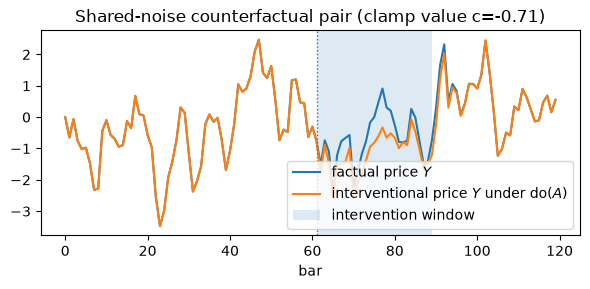

pre-onset paths identical: True


In [4]:
# One episode at moderate confounding. Seed 3 is chosen only so the example
# episode has a visually clear effect; nothing else depends on it.
prior = MarketDoTime(coupling_gamma=1.0, seed=3, **PRIOR_KW)
suite = build_market_suite(prior, n_episodes=3, T=120, seed=3)
ep = list(suite)[1]

# The intervention is a window of bars during which the flow A is clamped
# (hard intervention do(A := c)); the evaluation grids use hard clamps, the
# transfer tiers use soft (additive) interventions -- see paper section 3.
onset, end = min(ep.intervention.times), max(ep.intervention.times) + 1

plt.figure(figsize=(6, 3))
plt.plot(ep.x_obs[:, 2], label="factual price $Y$")                  # column 2 = price
plt.plot(ep.x_int[:, 2], label=r"interventional price $Y$ under do($A$)")
plt.axvspan(onset, end, alpha=0.15, label="intervention window")
plt.axvline(onset, ls=":", lw=1)
plt.xlabel("bar"); plt.legend(); plt.title(
    f"Shared-noise counterfactual pair (clamp value c={float(ep.intervention.values):+.2f})")
plt.tight_layout(); plt.show()

# The exactness guarantee, executed: before the onset the two trajectories
# must be bit-identical, because every noise increment is shared and the
# intervention has not started. The paper's tests assert this everywhere
# (including for the jump-diffusion extension).
pre_identical = torch.allclose(ep.x_obs[:onset, 2], ep.x_int[:onset, 2])
print("pre-onset paths identical:", pre_identical)
assert pre_identical

### Interventional vs. counterfactual — which one is this?

Pearl's ladder distinguishes **interventions** (rung 2: the distribution of $Y$ if we
*impose* $\mathrm{do}(A)$, with fresh exogenous noise) from **counterfactuals** (rung 3:
what $Y$ *would have been* in this specific realized world, holding the same noise). The
project uses both, in different roles, and the distinction is worth keeping sharp:

- **The estimand is interventional**: $E[Y \mid \mathrm{do}(A), \text{context}]$ — the
  conditional interventional distribution, exactly as formalized for the discrete-time
  construction this work extends.
- **The training targets are counterfactual realizations**: the pair above shares every
  noise draw, so `y_true` is the rung-3 outcome for *this* noise path.
- **Why that is consistent**: conditional on the pre-onset context, the post-onset noise
  is independent of everything observed. Marginalized over that unobserved noise, the
  counterfactual outcome has the *same conditional distribution* as the interventional
  one — so training on counterfactual pairs estimates the interventional law. (The
  equivalence needs the post-onset noise to be unobserved; it is.)
- **On the evaluation side**: ABIDES seed replay measures genuinely counterfactual
  outcomes (same seed, rung 3) — a valid *measurement* of the interventional claim in
  expectation, with the per-episode noise floor the paper quantifies. Real crypto data
  has no counterfactual at all, which is why the paper downgrades that tier to a factual
  task with a paired-ablation readout.


## 3. The paired do-head readout (requires checkpoints)

The paper's causal readout is the **paired do-head effect**: the causal model minus its
*do-ablated twin* — the identical architecture trained with the identical prior and seed,
but with the five intervention inputs (target, kind, value, window start/end) zeroed
throughout training and prediction. Both models see the same episodes; subtracting their
errors cancels the realized outcome, leaving the mean prediction *shift* that the
do-information induces.

Checkpoints are released with a DOI upon acceptance; if present locally, this cell
reproduces the Table-1 logic at smoke scale.

In [5]:
CKPT = Path("checkpoints/market_v4_soft/continuous_do_over_time_pfn_best.pt")
ABL = Path("checkpoints/market_v4_ablated_s42/continuous_do_over_time_pfn_best.pt")
HAVE_CKPT = CKPT.exists() and ABL.exists()
print("checkpoints available:", HAVE_CKPT)

def score(model, suite):
    """Per-episode signed errors of a model on a suite.

    The error is signed TOWARD the intervention direction (multiplied by
    sign(c)), so 'positive bias' always means 'over-predicts the impact of
    the trade' regardless of whether the episode's trade was a buy or sell.
    y_true is the exact counterfactual outcome from the shared-noise pair.
    """
    signed = []
    for ep in suite:
        p = model.predict(ep).reshape(-1)
        y = ep.y_true.reshape(-1)
        sgn = math.copysign(1.0, float(ep.intervention.values))
        signed.extend(sgn * float(a - b) for a, b in zip(p, y))
    return np.array(signed)

if HAVE_CKPT:
    prior = MarketDoTime(coupling_gamma=1.0, seed=SEED, **PRIOR_KW)
    suite = build_market_suite(prior, n_episodes=60, T=120, seed=SEED)
    models = {
        # the paper's model and its matched twin:
        "M-DoT-PFN (causal)": get("market-dotpfn", checkpoint=str(CKPT)),
        "do-ablated twin": get("ablated-dotpfn", checkpoint=str(ABL)),
        # classical foils, each fitted per episode on pre-onset data only:
        "AlmgrenChriss": get("AlmgrenChriss"),      # levels OLS -> confounded
        "SquareRootLaw": get("SquareRootLaw"),      # zero fitted parameters
        "Mean": get("Mean"),                        # impact-blind reference
    }
    errs = {n: score(m, suite) for n, m in models.items()}
    print(f"\n{'method':>20} {'signed bias':>12} {'rmse':>8}")
    for n, e in errs.items():
        print(f"{n:>20} {e.mean():>+12.3f} {np.sqrt((e**2).mean()):>8.3f}")

    # The headline readout: identical episodes, so the difference of the two
    # models' errors equals the difference of their predictions -- realized
    # outcomes cancel. A positive delta means the do-information moved the
    # prediction toward the impact direction.
    delta = errs["M-DoT-PFN (causal)"] - errs["do-ablated twin"]
    print(f"\npaired do-head effect (causal - ablated): {delta.mean():+.3f}"
          f"  (paper, full scale at gamma=1: causal bias -0.06 vs ablated -0.74)")

    # Expect at this smoke scale: the ablated twin sits on Mean (they are the
    # same impact-blind forecast), Almgren-Chriss overshoots (confounded
    # slope), and the causal model is the least biased.
else:
    print("skipped - obtain checkpoints (DOI on acceptance) and re-run")

checkpoints available: True



              method  signed bias     rmse
  M-DoT-PFN (causal)       +0.095    1.017
     do-ablated twin       -0.628    1.520
       AlmgrenChriss       +1.121    2.034
       SquareRootLaw       +0.159    1.404
                Mean       -0.627    1.520

paired do-head effect (causal - ablated): +0.723  (paper, full scale at gamma=1: causal bias -0.06 vs ablated -0.74)


## 4. Off-prior stress (exact counterfactuals outside the prior's class)

Is the synthetic result circular — a model evaluated on its own prior? The stress test
answers by generating episodes from mechanisms the prior **cannot express** (price→flow
feedback, compound-Poisson jumps, saturating impact), while keeping counterfactuals exact
(the simulator shares all noise draws between the arms). An *on-prior control* through the
same standalone simulator reproduces the main grid's numbers, so any shift is attributable
to the misspecification itself (paper §5.1, Table `tab:stress`).

Here we run two baselines on two generators; the PFN rows need checkpoints (same guard
as §3).

In [6]:
# The stress generators live in the evaluation script; load it as a module so
# this notebook exercises exactly the code the paper ran (no re-implementation).
import importlib.util
spec = importlib.util.spec_from_file_location("stress", "scripts/06_offprior_stress.py")
stress = importlib.util.module_from_spec(spec)
spec.loader.exec_module(stress)

for cname, kw in [("control", {}),               # inside the prior family
                  ("saturation", {"saturate": True})]:  # impact enters as 2*tanh(A/2)
    # A fresh RandomState per configuration so both configurations see the
    # same parameter draws -- differences are due to the mechanism, not luck.
    rng = np.random.RandomState(SEED)
    eps = [stress.simulate_episode(rng, scm_id=i, **kw) for i in range(40)]

    sq = get("SquareRootLaw"); ac = get("AlmgrenChriss")
    def bias(model):
        s = []
        for ep in eps:
            p = float(model.predict(ep).reshape(-1)[0])
            y = float(ep.y_true.reshape(-1)[0])   # exact counterfactual target
            s.append(math.copysign(1.0, float(ep.intervention.values)) * (p - y))
        return float(np.mean(s))
    print(f"{cname:>11}: sqrt-law bias {bias(sq):+.3f}   Almgren-Chriss bias {bias(ac):+.3f}")

print("(paper, n=500: AC +0.82 control / +0.95 saturation; PFN stays within +-0.16 everywhere)")

    control: sqrt-law bias +0.060   Almgren-Chriss bias +0.988
 saturation: sqrt-law bias +0.182   Almgren-Chriss bias +1.052
(paper, n=500: AC +0.82 control / +0.95 saturation; PFN stays within +-0.16 everywhere)


## 5. Full-scale reproduction map

| Paper artifact | Script | Runtime (CPU) |
|---|---|---|
| Fig. 1 (confounding law) | `scripts/01_bias_vs_gamma.py` | ~20 min |
| Fig. 2 / §5 grid | `scripts/01b_methods_vs_gamma.py` | ~40 min |
| Figures (render) | `scripts/01c_figures.py`, `scripts/01d_forest_figure.py` | seconds |
| Table 1 ABIDES column + ground truth | `scripts/03_abides_study.py --n-episodes 1000 --seed0 1000 --intervention-kind soft` | ~1 h |
| Table 1 crypto columns | `scripts/04_crypto_transfer.py --symbol {BTC,ETH,SOL}USDT` | ~10 min each |
| Placebo tests | `scripts/04b_placebo_test.py --symbol ...` | ~10 min each |
| Sqrt-law prefactor sensitivity | `scripts/04c_sqrt_sensitivity.py` | ~15 min |
| Table 3 (calibration) | `scripts/05_calibration.py` | ~30 min |
| Conformal recalibration | `scripts/05b_conformal.py` | ~1 h |
| Table 2 (off-prior stress) | `scripts/06_offprior_stress.py` | ~25 min |
| Generic-checkpoint + prior-attribution control | `scripts/07_generic_baseline.py` | ~2 h |
| Training (GPU) | `scripts/02_train_market_pfn.py --config configs/train_market.yaml --coupling-gamma-power 3 --intervention-kind-probs 0.5 0.5 0.0` | ~2 h on one A100 |

**Protocol invariants** (paper §5–§6): the ablated twin shares recipe *and* seed; all
exploratory ABIDES analysis used seeds 0–999 and the reported numbers are one frozen
evaluation on seeds 1000–1999; every CI is an episode-level bootstrap with $B=10^4$;
every prior extension ships a reduction test (feature off ≡ stock prior) — see `tests/`.
